In [1]:
import numpy as np
import pandas as pd

# Train-Test Split
from sklearn.model_selection import train_test_split

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Classification Model
from sklearn.linear_model import LogisticRegression

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("final_data.csv")
df

,blood_pressure,cholesterol,blood_sugar,max_heart_rate,oldpeak,smoking,family_history,chest_pain,heart_disease
0,140,188.0,101,162,1.28,2,1,2,1
1,138,251.0,132,146,0.48,0,0,1,0
2,131,286.0,132,154,1.73,2,1,1,1
3,150,223.0,140,148,0.18,0,0,0,0
4,150,192.0,103,183,0.75,1,0,0,0
...,...,...,...,...,...,...,...,...,...
1365,126,267.0,131,174,0.98,0,0,0,0
1366,135,217.0,110,148,1.27,2,1,1,0
1367,148,227.0,120,138,0.43,0,1,1,0
1368,150,231.0,151,136,1.50,0,0,1,1


In [4]:
X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

In [5]:
split_ratios = {
    "80-20": 0.20,
    "70-30": 0.30,
    "60-40": 0.40
}

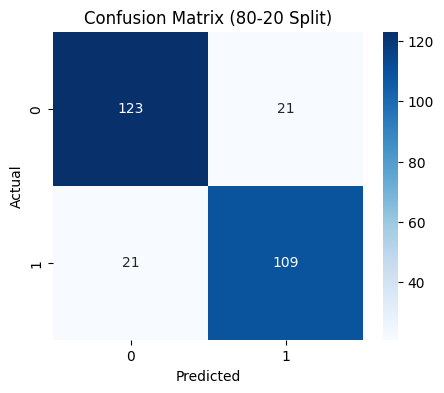

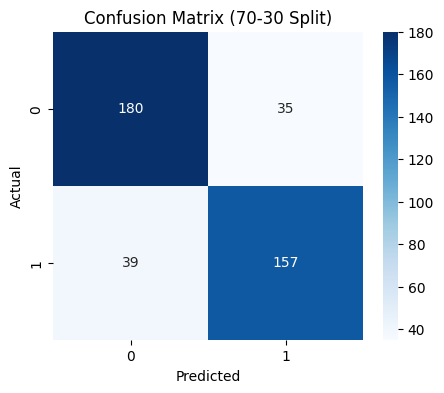

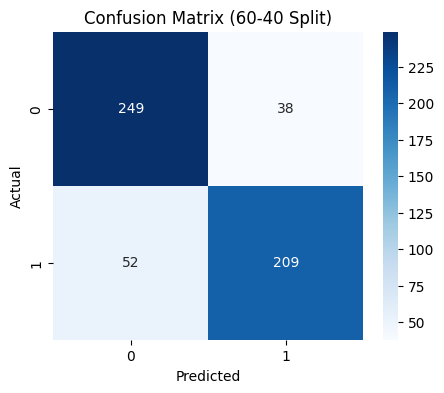

In [8]:
accuracies = []

for name, test_size in split_ratios.items():

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=42,
        stratify=y
    )

    model = LogisticRegression(max_iter=5000)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    # Confusion Matrix Plot
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix ({name} Split)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


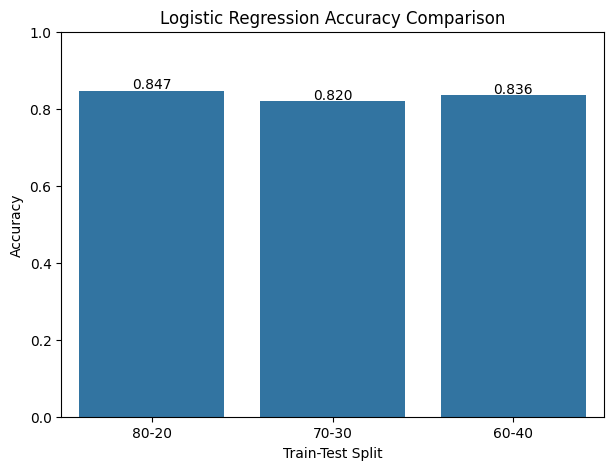

In [9]:
plt.figure(figsize=(7,5))
sns.barplot(x=list(split_ratios.keys()), y=accuracies)

for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.005, f"{acc:.3f}", ha='center')

plt.title('Logistic Regression Accuracy Comparison')
plt.xlabel('Train-Test Split')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.show()

In [10]:
X = df.drop("heart_disease", axis=1)
y = df["heart_disease"]

# Final 80-20 Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Train Final Model
final_model = LogisticRegression(max_iter=5000)
final_model.fit(X_train, y_train)

# Evaluate Final Model
y_pred = final_model.predict(X_test)

print("Final Model Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Final Model Accuracy: 0.8467

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       144
           1       0.84      0.84      0.84       130

    accuracy                           0.85       274
   macro avg       0.85      0.85      0.85       274
weighted avg       0.85      0.85      0.85       274



In [13]:
print(final_model.n_features_in_)
print(X_train.columns)

8
Index(['blood_pressure', 'cholesterol', 'blood_sugar', 'max_heart_rate',
       'oldpeak', 'smoking', 'family_history', 'chest_pain'],
      dtype='object')


In [24]:
import pandas as pd

def predict_heart_disease():
    print("\n===== Heart Disease Prediction System =====\n")

    blood_pressure = int(input("Blood Pressure / Systolic BP (90-200): "))
    cholesterol = int(input("Cholesterol Level (120-400 mg/dL): "))
    blood_sugar = int(input("Blood Sugar (70-250 mg/dL): "))
    max_heart_rate = int(input("Maximum Heart Rate (70-210): "))
    oldpeak = float(input("Oldpeak / ST Depression (0-6): "))

    print("\nSmoking Status:")
    print("0 = Never")
    print("1 = Former Smoker")
    print("2 = Current Smoker")
    smoking = int(input("Enter choice: "))

    print("\nFamily History:")
    print("0 = No")
    print("1 = Yes")
    family_history = int(input("Enter choice: "))

    print("\nChest Pain:")
    print("0 = No Pain")
    print("1 = Mild Pain")
    print("2 = Moderate Pain")
    print("3 = Severe Pain")
    chest_pain = int(input("Enter choice: "))

    user_data = pd.DataFrame([{
        "blood_pressure": blood_pressure,
        "cholesterol": cholesterol,
        "blood_sugar": blood_sugar,
        "max_heart_rate": max_heart_rate,
        "oldpeak": oldpeak,
        "smoking": smoking,
        "family_history": family_history,
        "chest_pain": chest_pain
    }])

    prediction = final_model.predict(user_data)[0]

    print("\n===== Prediction Result =====")

    if prediction == 1:
        print("Heart Disease Risk Detected")
    else:
        print("No Significant Heart Disease Risk Detected")

In [ ]:
predict_heart_disease()


===== Heart Disease Prediction System =====



Blood Pressure / Systolic BP (90-200):  150
